# Embedding Categorization System Evaluator

This notebook implements an embedding-based product categorization system using OpenAI embeddings and FAISS for similarity search.

## Overview:
1. Load category data and create embeddings
2. Build FAISS index for fast similarity search
3. Evaluate on test data
4. Calculate comprehensive metrics
5. Visualize results

## 1. Setup and Imports

In [ ]:
# Install required packages (run this cell if needed)
# !pip install openai pandas numpy faiss-cpu scikit-learn matplotlib seaborn python-dotenv

In [23]:
# IMPORTS

import openai
import numpy as np
import pandas as pd
import faiss
import os
import time
import pickle
from typing import List, Tuple, Dict
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from openai import OpenAI
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('default')
sns.set_palette("husl")

print("All imports successful!")

All imports successful!


## 2. Configuration and API Setup

In [2]:
# Load environment variables
load_dotenv()

# Configuration
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
EMBEDDING_MODEL = "text-embedding-3-large"

# File paths (modify these according to your file locations)
CATEGORIES_FILE = "data/product_descriptions_enhanced.csv"
FULL_DATA_FILE = "data/product_info_01.csv"

# Embeddings storage configuration
EMBEDDINGS_DIR = "embeddings_cache"  # Directory to store embeddings
CATEGORY_EMBEDDINGS_FILE = f"{EMBEDDINGS_DIR}/category_embeddings.npy"
CATEGORY_NAMES_FILE = f"{EMBEDDINGS_DIR}/category_names.pkl"
FORCE_REGENERATE_EMBEDDINGS = False  # Set to True to force regeneration

# Dataset splitting parameters
TEST_SIZE = 0.01  # 20% for testing
VALIDATION_SIZE = 0.001  # 10% for validation (optional)
RANDOM_STATE = 41  # For reproducible splits

# Create embeddings directory if it doesn't exist
os.makedirs(EMBEDDINGS_DIR, exist_ok=True)

# Verify API key
if not OPENAI_API_KEY:
    print("⚠️ WARNING: OpenAI API key not found!")
    print("Please set OPENAI_API_KEY in your .env file or environment variables")
else:
    print("✅ OpenAI API key loaded successfully")
    
# Initialize OpenAI client
client = OpenAI(api_key=OPENAI_API_KEY)
print(f"✅ Using embedding model: {EMBEDDING_MODEL}")
print(f"✅ Dataset splitting: {TEST_SIZE*100}% test, {VALIDATION_SIZE*100}% validation")
print(f"✅ Embeddings cache directory: {EMBEDDINGS_DIR}")

✅ OpenAI API key loaded successfully
✅ Using embedding model: text-embedding-3-large
✅ Dataset splitting: 1.0% test, 0.1% validation
✅ Embeddings cache directory: embeddings_cache


## 3. Helper Functions

In [3]:
def get_embedding(text: str, model: str = EMBEDDING_MODEL, max_retries: int = 3) -> np.ndarray:
    """
    Get embedding for a text using OpenAI API with retry logic.
    
    Args:
        text: Text to embed
        model: OpenAI model to use
        max_retries: Maximum number of retries
        
    Returns:
        Numpy array of embedding
    """
    for attempt in range(max_retries):
        try:
            response = client.embeddings.create(
                input=text,
                model=model
            )
            embedding = response.data[0].embedding
            return np.array(embedding, dtype=np.float32)
        except Exception as e:
            if attempt == max_retries - 1:
                raise e
            print(f"Attempt {attempt + 1} failed: {e}. Retrying...")
            time.sleep(1)  # Wait before retry

def calculate_metrics(y_true: List[str], y_pred: List[str]) -> Dict:
    """
    Calculate comprehensive evaluation metrics.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        
    Returns:
        Dictionary with metrics
    """
    # Basic accuracy
    accuracy = accuracy_score(y_true, y_pred)
    
    # Get unique labels
    labels = sorted(list(set(y_true + y_pred)))
    
    # Precision, Recall, F1-score
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )
    
    # Macro and weighted averages
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    
    # Confusion matrix
    conf_matrix = confusion_matrix(y_true, y_pred, labels=labels)
    
    return {
        'accuracy': accuracy,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_precision,
        'weighted_recall': weighted_recall,
        'weighted_f1': weighted_f1,
        'per_class_precision': dict(zip(labels, precision)),
        'per_class_recall': dict(zip(labels, recall)),
        'per_class_f1': dict(zip(labels, f1)),
        'per_class_support': dict(zip(labels, support)),
        'confusion_matrix': conf_matrix,
        'labels': labels
    }

print("✅ Helper functions defined")

✅ Helper functions defined


## 4. Load and Process Category Data

In [4]:
# Load category data with robust CSV parsing
print("Loading category data...")

def load_csv_robust(file_path):
    """
    Robustly load CSV with different delimiters and encodings
    """
    # Common delimiters to try
    delimiters = [',', ';', '\t', '|']
    encodings = ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']
    
    for encoding in encodings:
        for delimiter in delimiters:
            try:
                print(f"Trying delimiter: '{delimiter}' with encoding: '{encoding}'")
                df = pd.read_csv(file_path, delimiter=delimiter, encoding=encoding)
                
                # Check if we got reasonable results
                if df.shape[1] > 1 and df.shape[0] > 0:
                    print(f"✅ Success! Using delimiter: '{delimiter}' and encoding: '{encoding}'")
                    return df
                    
            except Exception as e:
                continue
    
    # If all else fails, try with error handling
    try:
        print("Trying with error handling...")
        df = pd.read_csv(file_path, sep=None, engine='python', encoding='utf-8', on_bad_lines='skip')
        return df
    except Exception as e:
        raise Exception(f"Could not parse CSV file: {e}")

try:
    categories_df = load_csv_robust(CATEGORIES_FILE)
    print(f"✅ Loaded category data: {categories_df.shape}")
    print(f"Columns: {list(categories_df.columns)}")
    
    # Display first few rows
    display(categories_df.head())
    
except FileNotFoundError:
    print(f"❌ Error: File '{CATEGORIES_FILE}' not found!")
    print("Please make sure the file exists in the current directory.")
    print(f"Current working directory: {os.getcwd()}")
    
except Exception as e:
    print(f"❌ Error loading file: {e}")

Loading category data...
Trying delimiter: ',' with encoding: 'utf-8'
Trying delimiter: ';' with encoding: 'utf-8'
✅ Success! Using delimiter: ';' and encoding: 'utf-8'
✅ Loaded category data: (362, 2)
Columns: ['encodeNameEN', 'category_description']


,encodeNameEN,category_description
0,body/atopic-dermatitis/bath-shower,**Title:** Bath and Shower Solutions for Atopi...
1,body/atopic-dermatitis/specific-care,**Title:** Specialized Care for Atopic Dermati...
2,body/bath-shower,**Title:** Body Care and Bath/Shower Essential...
3,body/bath-shower/dryness-dehydration,**Title:** Body and Bath Products for Dryness ...
4,body/bath-shower/psoriasis,**Title:** Psoriasis Body and Bath Products: S...


In [5]:
# Check required columns and get unique categories
required_columns = ['encodeNameEN', 'category_description']
missing_columns = [col for col in required_columns if col not in categories_df.columns]

if missing_columns:
    print(f"❌ Missing required columns: {missing_columns}")
    print(f"Available columns: {list(categories_df.columns)}")
else:
    print("✅ All required columns found")
    
    # Get unique categories
    unique_categories = categories_df.drop_duplicates(subset=['encodeNameEN'])
    print(f"\n📊 Dataset Statistics:")
    print(f"   Total rows: {len(categories_df)}")
    print(f"   Unique categories: {len(unique_categories)}")
    
    # Show category distribution
    category_counts = categories_df['encodeNameEN'].value_counts()
    print(f"\n🔍 Top 10 most common categories:")
    print(category_counts.head(10))

✅ All required columns found

📊 Dataset Statistics:
   Total rows: 362
   Unique categories: 362

🔍 Top 10 most common categories:
encodeNameEN
body/atopic-dermatitis/bath-shower        1
body/atopic-dermatitis/specific-care      1
body/bath-shower                          1
body/bath-shower/dryness-dehydration      1
body/bath-shower/psoriasis                1
body/bath-shower/seborrheic-dermatitis    1
body/beauty-tech                          1
body/bust-care                            1
body/cellulite-control                    1
body/dehydration/moisturizers             1
Name: count, dtype: int64


## 5. Create Category Embeddings

In [6]:
# Create embeddings for categories
print("🚀 Creating category embeddings...")
print("This may take a few minutes depending on the number of categories.\n")

embeddings = []
category_names = []
failed_categories = []

for idx, row in unique_categories.iterrows():
    try:
        embedding = get_embedding(row['category_description'])
        embeddings.append(embedding)
        category_names.append(row['encodeNameEN'])
        
        if len(embeddings) % 10 == 0:
            print(f"✅ Processed {len(embeddings)}/{len(unique_categories)} categories...")
            
    except Exception as e:
        print(f"❌ Error processing category '{row['encodeNameEN']}': {e}")
        failed_categories.append(row['encodeNameEN'])
        continue

# Convert to numpy array
category_embeddings = np.array(embeddings, dtype=np.float32)

print(f"\n✅ Category embedding creation complete!")
print(f"   Successfully processed: {len(category_names)} categories")
print(f"   Failed: {len(failed_categories)} categories")
print(f"   Embedding dimension: {category_embeddings.shape[1]}")

if failed_categories:
    print(f"\n⚠️ Failed categories: {failed_categories}")

🚀 Creating category embeddings...
This may take a few minutes depending on the number of categories.

✅ Processed 10/362 categories...
✅ Processed 20/362 categories...
✅ Processed 30/362 categories...
✅ Processed 40/362 categories...
✅ Processed 50/362 categories...
✅ Processed 60/362 categories...
✅ Processed 70/362 categories...
✅ Processed 80/362 categories...
✅ Processed 90/362 categories...
✅ Processed 100/362 categories...
✅ Processed 110/362 categories...
✅ Processed 120/362 categories...
✅ Processed 130/362 categories...
✅ Processed 140/362 categories...
✅ Processed 150/362 categories...
✅ Processed 160/362 categories...
✅ Processed 170/362 categories...
✅ Processed 180/362 categories...
✅ Processed 190/362 categories...
✅ Processed 200/362 categories...
✅ Processed 210/362 categories...
✅ Processed 220/362 categories...
✅ Processed 230/362 categories...
✅ Processed 240/362 categories...
✅ Processed 250/362 categories...
✅ Processed 260/362 categories...
✅ Processed 270/362 cat

## 6. Build FAISS Index

In [7]:
# Build FAISS index for fast similarity search
print("🏗️ Building FAISS index...")

embedding_dimension = category_embeddings.shape[1]

# Create FAISS index (using L2 distance)
faiss_index = faiss.IndexFlatL2(embedding_dimension)

# Add category embeddings to index
faiss_index.add(category_embeddings)

print(f"✅ FAISS index built successfully!")
print(f"   Index contains: {faiss_index.ntotal} categories")
print(f"   Embedding dimension: {embedding_dimension}")

🏗️ Building FAISS index...
✅ FAISS index built successfully!
   Index contains: 362 categories
   Embedding dimension: 3072


## 7. Load and Process Product Data

In [8]:
# Load and process product data
print("📊 Loading product data...")
try:
    # Load the full product dataset
    full_df = pd.read_csv(FULL_DATA_FILE, delimiter=';')  # Try semicolon first
    print(f"✅ Loaded product data: {full_df.shape}")
    print(f"Columns: {list(full_df.columns)}")
    
    # Display first few rows to understand the data
    print("\n🔍 First few rows of original data:")
    display(full_df.head())
    
except Exception as e:
    print(f"❌ Error with semicolon delimiter: {e}")
    print("Trying with comma delimiter...")
    
    try:
        full_df = pd.read_csv(FULL_DATA_FILE, delimiter=',')
        print(f"✅ Loaded product data: {full_df.shape}")
        print(f"Columns: {list(full_df.columns)}")
        display(full_df.head())
        
    except FileNotFoundError:
        print(f"❌ Error: File '{FULL_DATA_FILE}' not found!")
        print("Please make sure the file exists in the current directory.")
        
    except Exception as e2:
        print(f"❌ Error loading data: {e2}")

📊 Loading product data...
❌ Error with semicolon delimiter: Error tokenizing data. C error: Expected 2 fields in line 3, saw 3

Trying with comma delimiter...
✅ Loaded product data: (15968, 7)
Columns: ['ref', 'itemDescriptionEN', 'brand', 'nameEN', 'encodeNameEN', 'title', 'description']


,ref,itemDescriptionEN,brand,nameEN,encodeNameEN,title,description
0,000785FR,Combo Spot on 1 Pipette Dogs L 20-40 Kg,Frontline,Pet Care,health-care/veterinary-products,Combo Spot on Pipette Dogs 20-40 Kg,"The simple itching, caused by fleas can be a..."
1,000946DK,Men Eau de Toilette,DKNY,Fragrances,men/perfumes/fragrances,Men Eau de Toilette,"Discover DKNY Men Eau de Toilette — a modern, ..."
2,023444DK,Be Delicious Fresh Blossom Body Mist,DKNY,Fragrances,fragrance/women,Be Delicious Fresh Blossom Body Mist,DKNY Be Delicious Fresh Blossom Body Mist is a...
3,000784FR,Combo Spot on 1 Pipette Dogs M 10-20 Kg,Frontline,Pet Care,health-care/veterinary-products,Spot-On 10-20 Kg,"Have a dog as a companion is great, even bette..."
4,025034DK,Be Delicious Ice Pop Citrus Splash Eau de Parfum,DKNY,Fragrances,fragrance/women,Be Delicious Ice Pop Citrus Splash Eau de Parfum,DKNY Be Delicious Ice Pop Citrus Splash Eau de...


In [9]:
# Create full_description column and process data
print("🔧 Processing product data...")

# Check for required columns
required_columns = ['brand', 'itemDescriptionEN', 'description', 'encodeNameEN']
missing_columns = [col for col in required_columns if col not in full_df.columns]

if missing_columns:
    print(f"❌ Missing required columns: {missing_columns}")
    print(f"Available columns: {list(full_df.columns)}")
    
    # Try to find similar column names
    print("\n🔍 Looking for similar column names...")
    available_cols = list(full_df.columns)
    for req_col in missing_columns:
        similar_cols = [col for col in available_cols if req_col.lower() in col.lower()]
        if similar_cols:
            print(f"   Similar to '{req_col}': {similar_cols}")
else:
    print("✅ All required columns found")
    
    # Handle missing values
    print("\n🧹 Cleaning data...")
    full_df['brand'] = full_df['brand'].fillna('')
    full_df['itemDescriptionEN'] = full_df['itemDescriptionEN'].fillna('')  
    full_df['description'] = full_df['description'].fillna('')
    
    # Create full_description column
    print("📝 Creating full_description column...")
    full_df['full_description'] = (
        full_df['brand'].astype(str) + ' ' + 
        full_df['itemDescriptionEN'].astype(str) + ' ' + 
        full_df['description'].astype(str)
    ).str.strip()
    
    # Remove rows with empty full_description
    initial_count = len(full_df)
    full_df = full_df[full_df['full_description'].str.len() > 0]
    final_count = len(full_df)
    
    print(f"✅ Created full_description column")
    print(f"   Removed {initial_count - final_count} rows with empty descriptions")
    print(f"   Final dataset size: {final_count} rows")
    
    # Show sample of created descriptions
    print(f"\n📄 Sample full_descriptions:")
    for i in range(min(3, len(full_df))):
        sample_desc = full_df.iloc[i]['full_description']
        category = full_df.iloc[i]['encodeNameEN']
        print(f"   [{category}]: {sample_desc[:100]}...")

🔧 Processing product data...
✅ All required columns found

🧹 Cleaning data...
📝 Creating full_description column...
✅ Created full_description column
   Removed 1 rows with empty descriptions
   Final dataset size: 15967 rows

📄 Sample full_descriptions:
   [health-care/veterinary-products]: Frontline Combo Spot on 1 Pipette Dogs L 20-40 Kg   The simple itching, caused by fleas can be annoy...
   [men/perfumes/fragrances]: DKNY Men Eau de Toilette  Discover DKNY Men Eau de Toilette — a modern, citrus aromatic fragrance de...
   [fragrance/women]: DKNY Be Delicious Fresh Blossom Body Mist DKNY Be Delicious Fresh Blossom Body Mist is a light, refr...


In [10]:
# Split dataset into test and validation sets
print("✂️ Splitting dataset...")

# First, let's see the category distribution
print(f"\n📊 Category distribution in full dataset:")
category_counts = full_df['encodeNameEN'].value_counts()
print(f"   Total categories: {len(category_counts)}")
print(f"   Total samples: {len(full_df)}")
print(f"\n🔍 Top 10 categories:")
print(category_counts.head(10))

# Categories with very few samples
low_sample_categories = category_counts[category_counts < 5]
if len(low_sample_categories) > 0:
    print(f"\n⚠️ Warning: {len(low_sample_categories)} categories have fewer than 5 samples")
    print("These may cause issues in stratified splitting.")

# Perform stratified split to maintain category proportions
try:
    # Split into train+val and test
    train_val_df, test_df = train_test_split(
        full_df,
        test_size=TEST_SIZE,
        stratify=full_df['encodeNameEN'],
        random_state=RANDOM_STATE
    )
    
    # Optional: Further split train_val into train and validation
    if VALIDATION_SIZE > 0:
        train_df, val_df = train_test_split(
            train_val_df,
            test_size=VALIDATION_SIZE/(1-TEST_SIZE),  # Adjust for already split data
            stratify=train_val_df['encodeNameEN'],
            random_state=RANDOM_STATE
        )
        
        print(f"✅ Dataset split completed:")
        print(f"   Training set: {len(train_df)} samples ({len(train_df)/len(full_df)*100:.1f}%)")
        print(f"   Validation set: {len(val_df)} samples ({len(val_df)/len(full_df)*100:.1f}%)")
        print(f"   Test set: {len(test_df)} samples ({len(test_df)/len(full_df)*100:.1f}%)")
    else:
        train_df = train_val_df
        val_df = None
        
        print(f"✅ Dataset split completed:")
        print(f"   Training set: {len(train_df)} samples ({len(train_df)/len(full_df)*100:.1f}%)")
        print(f"   Test set: {len(test_df)} samples ({len(test_df)/len(full_df)*100:.1f}%)")
        
except ValueError as e:
    print(f"⚠️ Stratified split failed: {e}")
    print("Falling back to random split...")
    
    # Fallback to random split
    train_val_df, test_df = train_test_split(
        full_df,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )
    
    if VALIDATION_SIZE > 0:
        train_df, val_df = train_test_split(
            train_val_df,
            test_size=VALIDATION_SIZE/(1-TEST_SIZE),
            random_state=RANDOM_STATE
        )
    else:
        train_df = train_val_df
        val_df = None
    
    print(f"✅ Random split completed:")
    print(f"   Training set: {len(train_df)} samples")
    print(f"   Test set: {len(test_df)} samples")
    if val_df is not None:
        print(f"   Validation set: {len(val_df)} samples")

# Display sample from test set
print(f"\n📋 Test set sample:")
display(test_df[['brand', 'itemDescriptionEN', 'encodeNameEN', 'full_description']].head())

✂️ Splitting dataset...

📊 Category distribution in full dataset:
   Total categories: 362
   Total samples: 15967

🔍 Top 10 categories:
encodeNameEN
fragrance/women                                    852
men/perfumes/fragrances                            400
skin/dehydration/specific-moisturizers             399
skin/cleansers-tonners/combination-to-oily-skin    338
skin/cleansers-tonners/normal-skin                 330
skin/global-anti-aging/specific-moisturizers       323
body/dehydration/moisturizers                      263
skin/masks-exfoliators/tissue-masks                261
skin/dark-spots/seruns                             261
body/bath-shower/dryness-dehydration               242
Name: count, dtype: int64

⚠️ Warning: 78 categories have fewer than 5 samples
These may cause issues in stratified splitting.
⚠️ Stratified split failed: Input contains NaN
Falling back to random split...
✅ Random split completed:
   Training set: 15791 samples
   Test set: 160 samples
   Validatio

,brand,itemDescriptionEN,encodeNameEN,full_description
13802,Nuxe,Sweet Lemon Lip Balm,skin/lip-care/dryness-dehydration,Nuxe Sweet Lemon Lip Balm Indulge in this hydr...
10263,Kerastase,Curl Manifesto Fondant Moisture Conditioner Cu...,hair/curly-hair/conditioners,Kerastase Curl Manifesto Fondant Moisture Cond...
6930,Needly,pH Balancing Toner,skin/cleansers-tonners/dry-skin,"Needly pH Balancing Toner Balance, hydrate, an..."
178,La Prairie,Skin Caviar Luxe Cream Sheer,skin/loss-firmness/specific-moisturizers,La Prairie Skin Caviar Luxe Cream Sheer Skin ...
2910,Heliocare,360º Fluid Spray Sunscreen Body,sun-tan/normal-skin/body,Heliocare 360º Fluid Spray Sunscreen Body Heli...


In [11]:
# Optional: Save the split datasets for future use
print("💾 Saving split datasets...")

# Save datasets
train_df.to_csv('train_data.csv', index=False)
test_df.to_csv('test_data.csv', index=False)

if val_df is not None:
    val_df.to_csv('validation_data.csv', index=False)
    print("✅ Saved datasets:")
    print("   • train_data.csv")
    print("   • test_data.csv") 
    print("   • validation_data.csv")
else:
    print("✅ Saved datasets:")
    print("   • train_data.csv")
    print("   • test_data.csv")

print(f"\n📊 Final dataset statistics:")
print(f"   Test set categories: {test_df['encodeNameEN'].nunique()}")
print(f"   Average description length: {test_df['full_description'].str.len().mean():.1f} characters")

💾 Saving split datasets...


✅ Saved datasets:
   • train_data.csv
   • test_data.csv
   • validation_data.csv

📊 Final dataset statistics:
   Test set categories: 90
   Average description length: 879.5 characters


In [12]:
# Check test data columns and statistics
required_test_columns = ['full_description', 'encodeNameEN']
missing_test_columns = [col for col in required_test_columns if col not in test_df.columns]

if missing_test_columns:
    print(f"❌ Missing required columns in test data: {missing_test_columns}")
    print(f"Available columns: {list(test_df.columns)}")
else:
    print("✅ All required test columns found")
    
    # Test data statistics
    print(f"\n📊 Test Data Statistics:")
    print(f"   Total test samples: {len(test_df)}")
    print(f"   Unique categories in test: {test_df['encodeNameEN'].nunique()}")
    
    # Show test category distribution
    test_category_counts = test_df['encodeNameEN'].value_counts()
    print(f"\n🔍 Top 10 categories in test data:")
    print(test_category_counts.head(10))
    
    # Check for categories in test that are not in training
    test_categories = set(test_df['encodeNameEN'].unique())
    train_categories = set(category_names)
    missing_in_train = test_categories - train_categories
    
    if missing_in_train:
        print(f"\n⚠️ Warning: {len(missing_in_train)} categories in test data are not in training data:")
        print(list(missing_in_train)[:10])  # Show first 10
    else:
        print("\n✅ All test categories are present in training data")

✅ All required test columns found

📊 Test Data Statistics:
   Total test samples: 160
   Unique categories in test: 90

🔍 Top 10 categories in test data:
encodeNameEN
fragrance/women                                    9
skin/cleansers-tonners/combination-to-oily-skin    8
men/perfumes/fragrances                            4
body/dehydration/moisturizers                      4
skin/masks-exfoliators/tissue-masks                4
skin/loss-firmness/specific-moisturizers           4
skin/eye-care/global-anti-aging                    3
skin/cleansers-tonners/dry-skin                    3
health-care/tights-orthoses                        3
body/feet                                          3
Name: count, dtype: int64

✅ All test categories are present in training data


## 8. Define Prediction Function

In [13]:
def predict_category(description: str, top_k: int = 1) -> List[Tuple[str, float]]:
    """
    Predict category for a given description.
    
    Args:
        description: Product description
        top_k: Number of top predictions to return
        
    Returns:
        List of tuples (category_name, distance)
    """
    # Get embedding for the description
    query_embedding = get_embedding(description)
    query_embedding = query_embedding.reshape(1, -1).astype(np.float32)
    
    # Search in FAISS index
    distances, indices = faiss_index.search(query_embedding, top_k)
    
    # Return results
    results = []
    for i in range(top_k):
        if i < len(indices[0]):
            category_idx = indices[0][i]
            distance = distances[0][i]
            category_name = category_names[category_idx]
            results.append((category_name, distance))
    
    return results

print("✅ Prediction function defined")

✅ Prediction function defined


## 9. Test Single Prediction (Optional)

In [14]:
# Test with a sample description
if len(test_df) > 0:
    # Use first test sample
    sample_description = test_df.iloc[0]['full_description']
    actual_category = test_df.iloc[0]['encodeNameEN']
    
    print("🧪 Testing single prediction:")
    print(f"\nDescription: {sample_description[:200]}...")
    print(f"\nActual category: {actual_category}")
    
    # Get top 3 predictions
    predictions = predict_category(sample_description, top_k=3)
    
    print(f"\nTop 3 predictions:")
    for i, (category, distance) in enumerate(predictions):
        status = "✅" if category == actual_category else "❌"
        print(f"  {i+1}. {category} (distance: {distance:.4f}) {status}")

🧪 Testing single prediction:

Description: Nuxe Sweet Lemon Lip Balm Indulge in this hydrating BIO &amp; Vegan Sweet Lemon Lip Balm with an irresistible lemon meringue fragrance.Dry or weakened lips!Its ultra-sensory melting texture and delici...

Actual category: skin/lip-care/dryness-dehydration

Top 3 predictions:
  1. makeup/lips/lipbalm (distance: 1.0198) ❌
  2. skin/lip-care/dryness-dehydration (distance: 1.2079) ✅
  3. makeup/lips/lipstick (distance: 1.2262) ❌


## 10. Run Full Evaluation

In [15]:
# Run evaluation on all test data
print("🚀 Running full evaluation...")
print("This may take several minutes depending on the test set size.\n")

predictions = []
actual_labels = []
failed_predictions = []

for idx, row in test_df.iterrows():
    try:
        # Get prediction
        pred_results = predict_category(row['full_description'], top_k=1)
        predicted_category = pred_results[0][0] if pred_results else "UNKNOWN"
        
        predictions.append(predicted_category)
        actual_labels.append(row['encodeNameEN'])
        
        if (len(predictions)) % 100 == 0:  # Updated to show progress every 100 samples
            print(f"✅ Processed {len(predictions)}/{len(test_df)} samples...")
            
    except Exception as e:
        print(f"❌ Error processing sample {idx}: {e}")
        predictions.append("ERROR")
        actual_labels.append(row['encodeNameEN'])
        failed_predictions.append(idx)

print(f"\n✅ Evaluation complete!")
print(f"   Processed: {len(predictions)} samples")
print(f"   Failed: {len(failed_predictions)} samples")

🚀 Running full evaluation...
This may take several minutes depending on the test set size.

✅ Processed 100/160 samples...

✅ Evaluation complete!
   Processed: 160 samples
   Failed: 0 samples


## 11. Calculate Metrics

In [16]:
# Calculate comprehensive metrics
print("📊 Calculating evaluation metrics...")

results = calculate_metrics(actual_labels, predictions)

# Add additional information
results['predictions'] = predictions
results['actual_labels'] = actual_labels
results['test_samples'] = len(test_df)
results['failed_predictions'] = failed_predictions

print("✅ Metrics calculated successfully!")

📊 Calculating evaluation metrics...
The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
✅ Metrics calculated successfully!


## 12. Display Results

In [17]:
# Print comprehensive evaluation report
print("="*60)
print("🎯 EMBEDDING CATEGORIZATION EVALUATION REPORT")
print("="*60)

print(f"\n📊 Dataset Info:")
print(f"   Test samples: {results['test_samples']}")
print(f"   Categories: {len(results['labels'])}")
print(f"   Failed predictions: {len(results['failed_predictions'])}")

print(f"\n🎯 Overall Performance:")
print(f"   Accuracy: {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)")
print(f"   Macro F1-Score: {results['macro_f1']:.4f}")
print(f"   Weighted F1-Score: {results['weighted_f1']:.4f}")

print(f"\n📈 Detailed Metrics:")
print(f"   Macro Precision: {results['macro_precision']:.4f}")
print(f"   Macro Recall: {results['macro_recall']:.4f}")
print(f"   Weighted Precision: {results['weighted_precision']:.4f}")
print(f"   Weighted Recall: {results['weighted_recall']:.4f}")

# Top performing categories
f1_scores = results['per_class_f1']
sorted_f1 = sorted(f1_scores.items(), key=lambda x: x[1], reverse=True)

print(f"\n🏆 Top 5 Best Performing Categories (by F1-Score):")
for i, (category, f1) in enumerate(sorted_f1[:100]):
    support = results['per_class_support'][category]
    print(f"   {i+1}. {category}: F1={f1:.4f} (support={support})")

print(f"\n⚠️ Top 5 Worst Performing Categories (by F1-Score):")
for i, (category, f1) in enumerate(sorted_f1[-100:]):
    support = results['per_class_support'][category]
    print(f"   {i+1}. {category}: F1={f1:.4f} (support={support})")

🎯 EMBEDDING CATEGORIZATION EVALUATION REPORT

📊 Dataset Info:
   Test samples: 160
   Categories: 138
   Failed predictions: 0

🎯 Overall Performance:
   Accuracy: 0.3688 (36.88%)
   Macro F1-Score: 0.2569
   Weighted F1-Score: 0.3824

📈 Detailed Metrics:
   Macro Precision: 0.2750
   Macro Recall: 0.2635
   Weighted Precision: 0.4541
   Weighted Recall: 0.3688

🏆 Top 5 Best Performing Categories (by F1-Score):
   1. body/exfoliators: F1=1.0000 (support=1)
   2. body/stubborn-fat: F1=1.0000 (support=1)
   3. hair/brushes-combs: F1=1.0000 (support=1)
   4. hair/colour/conditioners: F1=1.0000 (support=1)
   5. hair/contitioner/hair-loss: F1=1.0000 (support=1)
   6. hair/curly-hair/conditioners: F1=1.0000 (support=1)
   7. hair/shampoo-dry: F1=1.0000 (support=1)
   8. hair/shampoo/straightening: F1=1.0000 (support=1)
   9. health-care/contact-lenses: F1=1.0000 (support=1)
   10. health-care/diabetics: F1=1.0000 (support=1)
   11. health-care/earplugs: F1=1.0000 (support=2)
   12. health-c

## 13. Visualization - Performance by Category

<Figure size 1500x800 with 0 Axes>

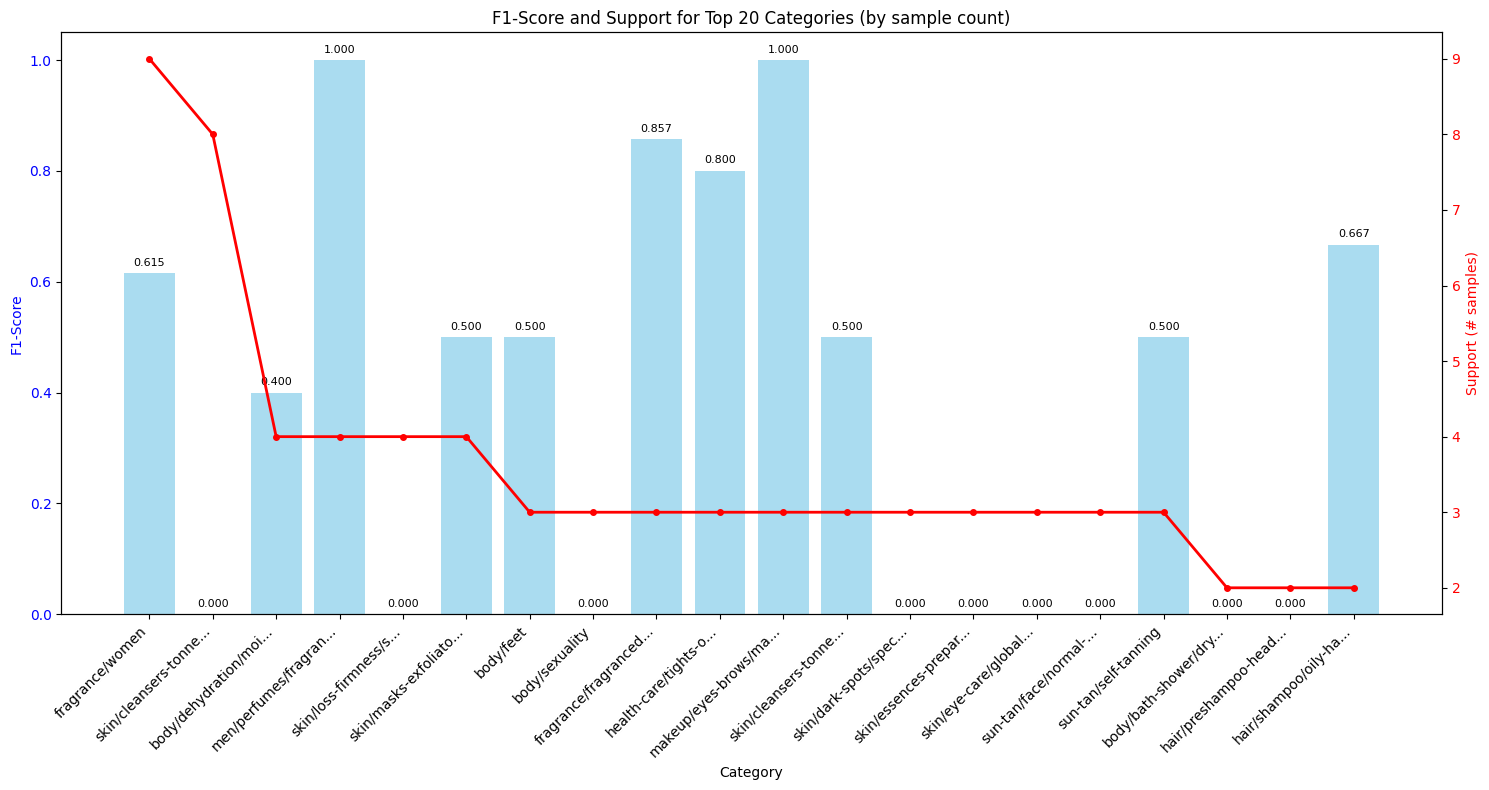

In [18]:
# Plot F1-scores by category (top 20)
plt.figure(figsize=(15, 8))

# Get top 20 categories by support
support_sorted = sorted(results['per_class_support'].items(), key=lambda x: x[1], reverse=True)
top_20_categories = [cat[0] for cat in support_sorted[:20]]

# Get F1 scores for top categories
top_f1_scores = [results['per_class_f1'][cat] for cat in top_20_categories]
top_support = [results['per_class_support'][cat] for cat in top_20_categories]

# Create subplot with two y-axes
fig, ax1 = plt.subplots(figsize=(15, 8))

# Bar plot for F1 scores
bars = ax1.bar(range(len(top_20_categories)), top_f1_scores, alpha=0.7, color='skyblue')
ax1.set_xlabel('Category')
ax1.set_ylabel('F1-Score', color='blue')
ax1.set_title('F1-Score and Support for Top 20 Categories (by sample count)')
ax1.set_xticks(range(len(top_20_categories)))
ax1.set_xticklabels([cat[:20] + '...' if len(cat) > 20 else cat for cat in top_20_categories], 
                    rotation=45, ha='right')
ax1.tick_params(axis='y', labelcolor='blue')

# Second y-axis for support
ax2 = ax1.twinx()
line = ax2.plot(range(len(top_20_categories)), top_support, color='red', marker='o', linewidth=2, markersize=4)
ax2.set_ylabel('Support (# samples)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add value labels on bars
for i, (bar, f1_score) in enumerate(zip(bars, top_f1_scores)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{f1_score:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 14. Confusion Matrix Visualization

Too many categories (138) for readable confusion matrix.
Showing confusion matrix for top 15 categories by support.


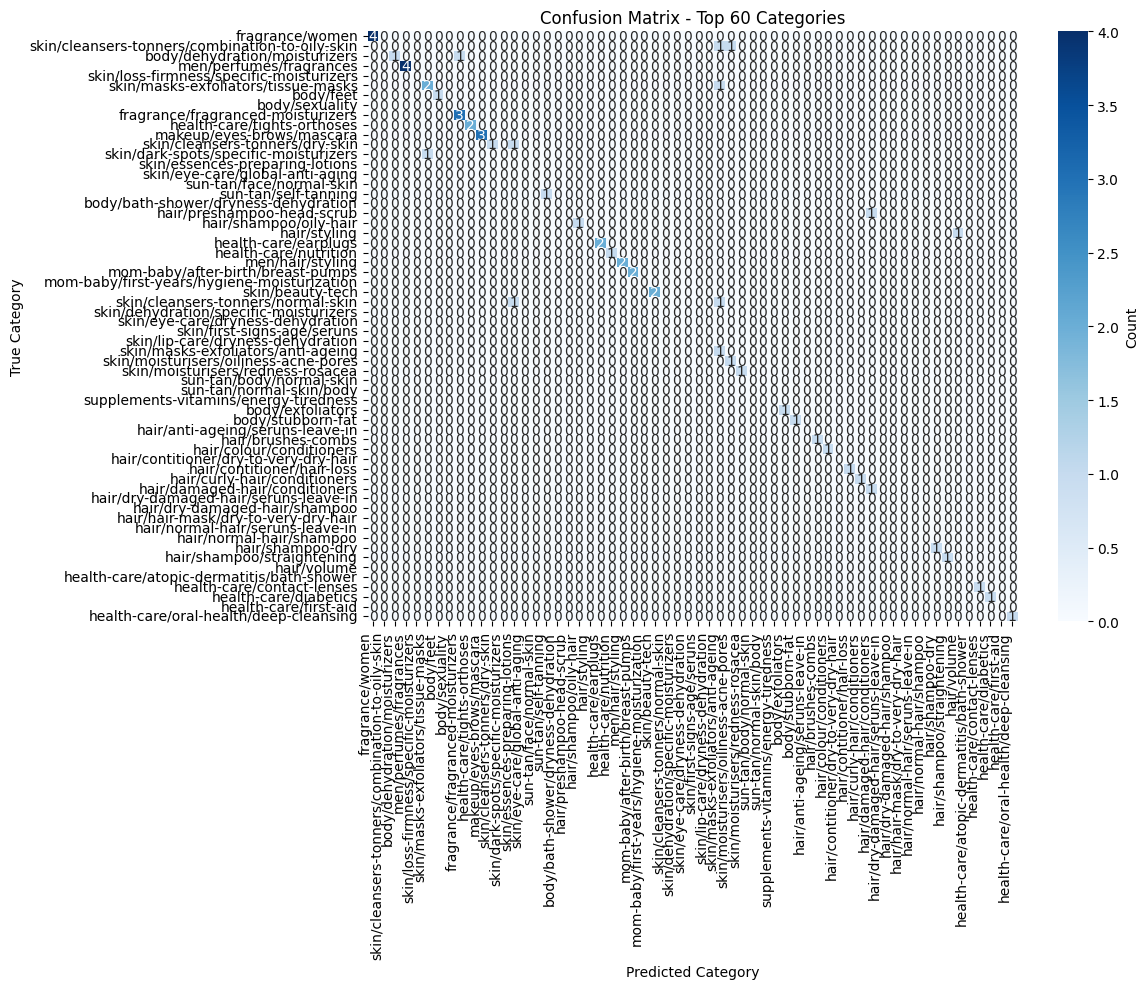

In [19]:
# Plot confusion matrix for top categories
conf_matrix = results['confusion_matrix']
labels = results['labels']

# If too many categories, show only top N by support
if len(labels) > 60:
    print(f"Too many categories ({len(labels)}) for readable confusion matrix.")
    print("Showing confusion matrix for top 15 categories by support.")
    
    # Get top 15 categories by support
    support_dict = results['per_class_support']
    top_categories = sorted(support_dict.items(), key=lambda x: x[1], reverse=True)[:60]
    top_labels = [cat[0] for cat in top_categories]
    
    # Filter confusion matrix
    label_indices = [labels.index(label) for label in top_labels if label in labels]
    filtered_conf_matrix = conf_matrix[np.ix_(label_indices, label_indices)]
    display_labels = top_labels
else:
    filtered_conf_matrix = conf_matrix
    display_labels = labels

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(filtered_conf_matrix, 
           xticklabels=[label[:60] + '...' if len(label) > 60 else label for label in display_labels], 
           yticklabels=[label[:60] + '...' if len(label) > 60 else label for label in display_labels],
           annot=True, 
           fmt='d', 
           cmap='Blues',
           cbar_kws={'label': 'Count'})

plt.title(f'Confusion Matrix - Top {len(display_labels)} Categories')
plt.xlabel('Predicted Category')
plt.ylabel('True Category')
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 15. Error Analysis

In [20]:
# Analyze misclassifications
print("🔍 ERROR ANALYSIS")
print("="*40)

# Create detailed results DataFrame
detailed_results = []
for i, (actual, predicted) in enumerate(zip(results['actual_labels'], results['predictions'])):
    detailed_results.append({
        'sample_id': i,
        'actual_category': actual,
        'predicted_category': predicted,
        'correct': actual == predicted,
        'description': test_df.iloc[i]['full_description'][:100] + '...' if len(test_df.iloc[i]['full_description']) > 100 else test_df.iloc[i]['full_description']
    })

detailed_df = pd.DataFrame(detailed_results)

# Show some incorrect predictions
incorrect_predictions = detailed_df[detailed_df['correct'] == False]
print(f"\nTotal incorrect predictions: {len(incorrect_predictions)}")

if len(incorrect_predictions) > 0:
    print(f"\n❌ Sample of incorrect predictions:")
    for i, row in incorrect_predictions.head(5).iterrows():
        print(f"\nSample {row['sample_id']}:")
        print(f"   Description: {row['description']}")
        print(f"   Actual: {row['actual_category']}")
        print(f"   Predicted: {row['predicted_category']}")

# Most common misclassification patterns
if len(incorrect_predictions) > 0:
    misclass_patterns = incorrect_predictions.groupby(['actual_category', 'predicted_category']).size().reset_index(name='count')
    misclass_patterns = misclass_patterns.sort_values('count', ascending=False)
    
    print(f"\n🔍 Top 10 misclassification patterns:")
    for i, row in misclass_patterns.head(299).iterrows():
        print(f"   {row['actual_category']} → {row['predicted_category']}: {row['count']} times")

🔍 ERROR ANALYSIS

Total incorrect predictions: 101

❌ Sample of incorrect predictions:

Sample 0:
   Description: Nuxe Sweet Lemon Lip Balm Indulge in this hydrating BIO &amp; Vegan Sweet Lemon Lip Balm with an irr...
   Actual: skin/lip-care/dryness-dehydration
   Predicted: makeup/lips/lipbalm

Sample 2:
   Description: Needly pH Balancing Toner Balance, hydrate, and brighten your skin with Needly pH Balancing Toner. T...
   Actual: skin/cleansers-tonners/dry-skin
   Predicted: skin/cleansers-tonners/sensitive-skin

Sample 3:
   Description: La Prairie Skin Caviar Luxe Cream Sheer  Skin Caviar Luxe Cream Sheeris anindulgent lifting andfirmi...
   Actual: skin/loss-firmness/specific-moisturizers
   Predicted: body/firming-care

Sample 4:
   Description: Heliocare 360º Fluid Spray Sunscreen Body Heliocare 360&ordm; fluid sprayspf50+provides smoothnesswi...
   Actual: sun-tan/normal-skin/body
   Predicted: sun-tan/sensitivity/face

Sample 5:
   Description: Galenic Confort Suprême Inten

## 17. Save Results

In [21]:
# Save detailed results to CSV
output_file = 'embedding_categorization_results.csv'
detailed_df.to_csv(output_file, index=False)
print(f"✅ Detailed results saved to: {output_file}")

# Save summary metrics
summary_file = 'categorization_summary.txt'
with open(summary_file, 'w') as f:
    f.write("EMBEDDING CATEGORIZATION EVALUATION SUMMARY\n")
    f.write("="*50 + "\n\n")
    f.write(f"Test samples: {results['test_samples']}\n")
    f.write(f"Categories: {len(results['labels'])}\n")
    f.write(f"Failed predictions: {len(results['failed_predictions'])}\n\n")
    f.write(f"Accuracy: {results['accuracy']:.4f}\n")
    f.write(f"Macro F1-Score: {results['macro_f1']:.4f}\n")
    f.write(f"Weighted F1-Score: {results['weighted_f1']:.4f}\n")
    f.write(f"Macro Precision: {results['macro_precision']:.4f}\n")
    f.write(f"Macro Recall: {results['macro_recall']:.4f}\n")
    f.write(f"Weighted Precision: {results['weighted_precision']:.4f}\n")
    f.write(f"Weighted Recall: {results['weighted_recall']:.4f}\n")

print(f"✅ Summary saved to: {summary_file}")

# Save per-category metrics
category_metrics = pd.DataFrame({
    'category': results['labels'],
    'precision': [results['per_class_precision'][cat] for cat in results['labels']],
    'recall': [results['per_class_recall'][cat] for cat in results['labels']],
    'f1_score': [results['per_class_f1'][cat] for cat in results['labels']],
    'support': [results['per_class_support'][cat] for cat in results['labels']]
})

category_metrics_file = 'category_metrics.csv'
category_metrics.to_csv(category_metrics_file, index=False)
print(f"✅ Per-category metrics saved to: {category_metrics_file}")

✅ Detailed results saved to: embedding_categorization_results.csv
✅ Summary saved to: categorization_summary.txt
✅ Per-category metrics saved to: category_metrics.csv


## 18. Summary and Conclusions

In [22]:
# Final summary
print("🎯 EVALUATION COMPLETE!")
print("="*50)

print(f"\n📊 Final Results Summary:")
print(f"   Overall Accuracy: {results['accuracy']*100:.2f}%")
print(f"   Macro F1-Score: {results['macro_f1']:.4f}")
print(f"   Weighted F1-Score: {results['weighted_f1']:.4f}")

print(f"\n📁 Generated Files:")
print(f"   • {output_file} - Detailed prediction results")
print(f"   • {summary_file} - Summary metrics")
print(f"   • {category_metrics_file} - Per-category performance")

print(f"\n💡 Key Insights:")
if results['accuracy'] > 0.8:
    print(f"   ✅ Excellent performance! The embedding-based categorization works very well.")
elif results['accuracy'] > 0.6:
    print(f"   👍 Good performance! There's room for improvement but the system is quite effective.")
elif results['accuracy'] > 0.4:
    print(f"   ⚠️ Moderate performance. Consider improving category descriptions or using more sophisticated models.")
else:
    print(f"   ❌ Poor performance. The system needs significant improvements.")

print(f"\n🚀 Next Steps:")
print(f"   • Analyze misclassification patterns to improve category descriptions")
print(f"   • Consider using larger embedding models for better performance")
print(f"   • Experiment with different similarity metrics")
print(f"   • Add more training data for poorly performing categories")

print(f"\n🎉 Thank you for using the Embedding Categorization System Evaluator!")

🎯 EVALUATION COMPLETE!

📊 Final Results Summary:
   Overall Accuracy: 36.88%
   Macro F1-Score: 0.2569
   Weighted F1-Score: 0.3824

📁 Generated Files:
   • embedding_categorization_results.csv - Detailed prediction results
   • categorization_summary.txt - Summary metrics
   • category_metrics.csv - Per-category performance

💡 Key Insights:
   ❌ Poor performance. The system needs significant improvements.

🚀 Next Steps:
   • Analyze misclassification patterns to improve category descriptions
   • Consider using larger embedding models for better performance
   • Experiment with different similarity metrics
   • Add more training data for poorly performing categories

🎉 Thank you for using the Embedding Categorization System Evaluator!
